In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df=pd.read_csv("WELFake_Dataset.csv/FakeNews.csv")

In [3]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [5]:
df.shape

(72134, 4)

In [6]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [8]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [11]:
df["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

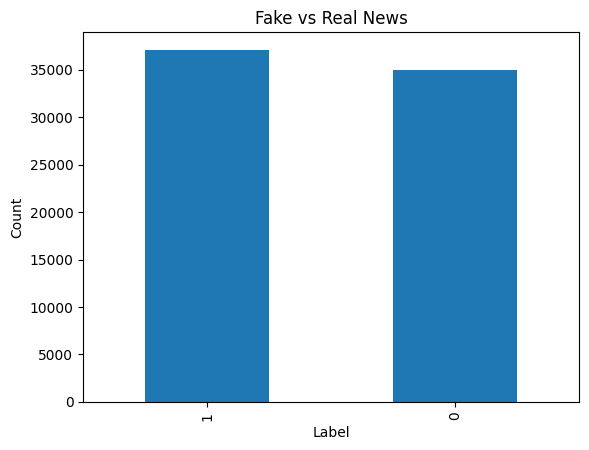

In [12]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Fake vs Real News")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [13]:
df= df.drop(columns=['Unnamed: 0'])
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [14]:
df=df.dropna()
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [15]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(63121, 3)

In [17]:
df['content']=df['title']+" "+df['text']

In [18]:
df[['title','text','content']].head()

,title,text,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,About Time! Christian Group Sues Amazon and SP...


In [ ]:
#text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
df["content"]=df["content"].apply(clean_text)

In [22]:
X=df["content"]
y=df["label"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (50496,)
X_test : (12625,)
y_train: (50496,)
y_test : (12625,)


In [25]:
vectorizer=TfidfVectorizer(stop_words="english")

In [26]:
X_train=vectorizer.fit_transform(X_train)

In [27]:
X_test=vectorizer.transform(X_test)

In [29]:
model=LogisticRegression(max_iter=1000)

In [30]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred=model.predict(X_test)

In [32]:
accuracy=accuracy_score(y_test, y_pred)
print("accuracy: ", accuracy)

accuracy:  0.9533465346534653


In [33]:
print("accuracy: ", accuracy*100)

accuracy:  95.33465346534653


In [34]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[6662  297]
 [ 292 5374]]


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      6959
           1       0.95      0.95      0.95      5666

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



In [40]:
news = input("Enter News: ")

news = clean_text(news)

news_vector = vectorizer.transform([news])

prediction = model.predict(news_vector)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Real News
